# Divergence diagnostics (partial pooling, "others" excluded)

After dropping the "other" segment, the partial pooling model now shows 60 divergences. This is up from 8 divergences including the "others" covariate. This section investigates potential causes.

In [4]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import matplotlib.pyplot as plt

print("Imports loaded.")

Imports loaded.


In [5]:
panel = pd.read_parquet("../data/customer_panel.parquet")
outcome = panel["churned"].values
segment_idx = panel["segment_idx"].values
n_segments = panel["segment_idx"].nunique()
print(f"Segments: {n_segments}")
print(f"Customers per segment:")
for i, name in panel.groupby("segment_idx")["segment_name"].first().items():
    n = (segment_idx == i).sum()
    rate = outcome[segment_idx == i].mean()
    print(f"  {name}: {n} customers, churn rate {rate:.1%}")

Segments: 10
Customers per segment:
  Belgium: 27 customers, churn rate 40.7%
  France: 93 customers, churn rate 35.5%
  Germany: 107 customers, churn rate 35.5%
  Italy: 17 customers, churn rate 41.2%
  Netherlands: 22 customers, churn rate 72.7%
  Portugal: 24 customers, churn rate 50.0%
  Spain: 39 customers, churn rate 46.2%
  Sweden: 19 customers, churn rate 73.7%
  Switzerland: 21 customers, churn rate 42.9%
  United Kingdom: 5349 customers, churn rate 51.1%


## 1. Reproduce the problem

Fit the partial pooling model with the original specification to confirm the divergence count.

In [6]:
with pm.Model() as model_orig:
    mu = pm.Normal("mu", 0, 1)
    tau = pm.HalfNormal("tau", 1)
    alpha_offset = pm.Normal("alpha_offset", 0, 1, shape=n_segments)
    alpha = pm.Deterministic("alpha", mu + tau * alpha_offset)
    p = pm.math.sigmoid(alpha[segment_idx])
    y = pm.Bernoulli("y", p=p, observed=outcome)
    trace_orig = pm.sample(1000, tune=1000, cores=1, random_seed=42, progressbar=True)

div_orig = trace_orig.sample_stats["diverging"].sum().item()
print(f"Divergences (original): {div_orig}")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu, tau, alpha_offset]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 325 seconds.
There were 60 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Divergences (original): 60


## 2. Where are the divergences?

Check if divergences cluster at low tau (funnel geometry) or are spread across the posterior.

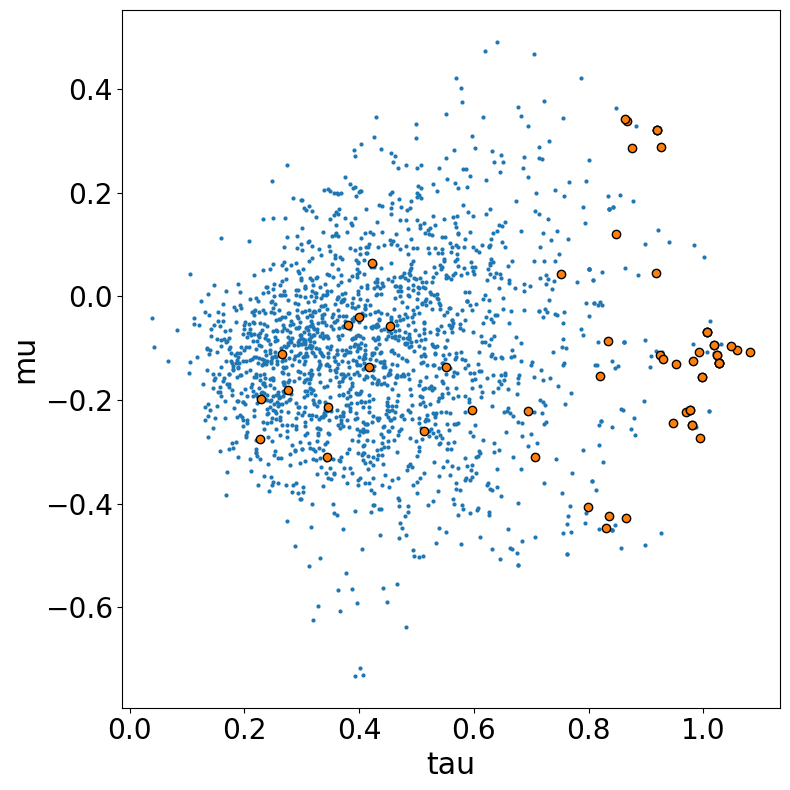

Mean tau (all): 0.457
Mean tau (divergent): 0.810
Divergences with tau < 0.1: 0 / 60


In [7]:
az.plot_pair(trace_orig, var_names=["tau", "mu"], divergences=True, figsize=(8, 8))
plt.tight_layout()
plt.show()

tau_samples = trace_orig.posterior["tau"].values.flatten()
div_mask = trace_orig.sample_stats["diverging"].values.flatten()
tau_div = tau_samples[div_mask]
print(f"Mean tau (all): {tau_samples.mean():.3f}")
print(f"Mean tau (divergent): {tau_div.mean():.3f}")
print(f"Divergences with tau < 0.1: {(tau_div < 0.1).sum()} / {len(tau_div)}")

In [8]:
summary = az.summary(trace_orig, var_names=["mu", "tau", "alpha"], round_to=3)
print(summary.to_string())

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
mu       -0.107  0.173  -0.451    0.213      0.011    0.009   272.067   306.054  1.008
tau       0.457  0.200   0.131    0.847      0.016    0.017   205.883    84.324  1.009
alpha[0] -0.239  0.284  -0.767    0.274      0.008    0.006  1326.376  1369.436  1.002
alpha[1] -0.472  0.204  -0.845   -0.087      0.005    0.004  1411.945  1170.338  1.001
alpha[2] -0.493  0.192  -0.840   -0.122      0.006    0.005  1150.694   969.347  1.001
alpha[3] -0.197  0.330  -0.828    0.426      0.011    0.009   921.820   710.496  1.008
alpha[4]  0.411  0.392  -0.274    1.111      0.018    0.013   509.177   600.915  1.005
alpha[5] -0.074  0.291  -0.586    0.482      0.009    0.007  1169.396  1305.247  1.002
alpha[6] -0.131  0.258  -0.635    0.317      0.007    0.006  1425.424  1294.750  1.003
alpha[7]  0.394  0.398  -0.302    1.120      0.016    0.013   656.625  1068.153  1.004
alpha[8] -0.198  0.314  -0.754    0.385    

## 3. Is the prior too restrictive?

The UK dominates with 93% of customers, so the model may be struggling to reconcile the massive UK segment with much smaller ones.
If the HalfNormal(1) prior on τ is too restrictive given the actual between-segment heterogeneity, widening it may help. Widening the prior on τ to HalfNormal(2) puts more prior mass at large τ values, which shifts the posterior toward higher τ and slightly changes the geometry.

The model:

$$\text{logit}(p_i) = \alpha_{j[i]}$$
$$\alpha_j \sim \mathcal{N}(\mu, \tau)$$
$$\mu \sim \mathcal{N}(0, 1)$$
$$\tau \sim \text{HalfNormal}(2)$$

In [9]:
with pm.Model() as model_wide:
    mu = pm.Normal("mu", 0, 1)
    tau = pm.HalfNormal("tau", 2)  # widened prior
    alpha_offset = pm.Normal("alpha_offset", 0, 1, shape=n_segments)
    alpha = pm.Deterministic("alpha", mu + tau * alpha_offset)
    p = pm.math.sigmoid(alpha[segment_idx])
    y = pm.Bernoulli("y", p=p, observed=outcome)
    trace_wide = pm.sample(1000, tune=1000, cores=1, random_seed=42, progressbar=True)

div_wide = trace_wide.sample_stats["diverging"].sum().item()
print(f"Divergences (tau prior HalfNormal(2)): {div_wide}")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu, tau, alpha_offset]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 300 seconds.
There were 23 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Divergences (tau prior HalfNormal(2)): 23


## 4. Is the step size too large?

The 60 divergences are concentrated at high values of τ, indicating potential step-size sensitivity at the boundary of the posterior's typical set. The partial pooling model was initially fit with default sampler settings. Increasing `target_accept` could resolve this by forcing NUTS to take smaller steps resolving typical funnel-geometry divergences.

So, the model has again a HalfNormal(1) prior, but this time with target_accept=0.95 (instead of the 0.80 default).

In [10]:
with pm.Model() as model_ta:
    mu = pm.Normal("mu", 0, 1)
    tau = pm.HalfNormal("tau", 1)
    alpha_offset = pm.Normal("alpha_offset", 0, 1, shape=n_segments)
    alpha = pm.Deterministic("alpha", mu + tau * alpha_offset)
    p = pm.math.sigmoid(alpha[segment_idx])
    y = pm.Bernoulli("y", p=p, observed=outcome)
    trace_ta = pm.sample(1000, tune=1500, target_accept=0.95, cores=1, random_seed=42, progressbar=True)

div_ta = trace_ta.sample_stats["diverging"].sum().item()
print(f"Divergences (target_accept=0.95): {div_ta}")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu, tau, alpha_offset]


Output()

Sampling 2 chains for 1_500 tune and 1_000 draw iterations (3_000 + 2_000 draws total) took 631 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Divergences (target_accept=0.95): 1


In [11]:
# Check r_hat and ESS for the target_accept=0.95 model
summary_ta = az.summary(trace_ta, var_names=["mu", "tau", "alpha"], round_to=3)
print(summary_ta.to_string())
print()
rhat_max = summary_ta["r_hat"].max()
ess_min = summary_ta["ess_bulk"].min()
print(f"Max r_hat: {rhat_max:.3f} (should be < 1.01)")
print(f"Min ESS (bulk): {ess_min:.0f} (should be > 400)")
if rhat_max < 1.01 and ess_min > 400:
    print("Chain has converged. The observed divergence appears substantively harmless.")
else:
    print("WARNING: Chain may not have fully converged. Consider further tuning.")

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
mu       -0.101  0.177  -0.434    0.243      0.007    0.006   699.397   647.104  1.001
tau       0.454  0.202   0.130    0.862      0.009    0.007   493.636   537.320  1.001
alpha[0] -0.254  0.306  -0.819    0.348      0.007    0.007  2039.926  1502.793  1.000
alpha[1] -0.484  0.206  -0.855   -0.076      0.005    0.005  1529.185  1038.705  1.001
alpha[2] -0.486  0.195  -0.858   -0.118      0.005    0.005  1636.850   831.770  1.001
alpha[3] -0.231  0.356  -0.883    0.420      0.008    0.013  1969.959  1430.551  1.000
alpha[4]  0.421  0.392  -0.248    1.176      0.012    0.008  1011.882  1480.124  1.003
alpha[5] -0.053  0.302  -0.578    0.566      0.007    0.007  2045.919  1512.957  1.000
alpha[6] -0.151  0.248  -0.591    0.332      0.005    0.006  2344.159  1591.059  1.001
alpha[7]  0.393  0.393  -0.268    1.157      0.012    0.010   966.123  1073.745  1.001
alpha[8] -0.199  0.331  -0.839    0.412    

## 5. Summary

In [12]:
print("=== Divergence summary ===")
print(f"Original (HalfNormal(1), target_accept=0.8): {div_orig}")
print(f"Wider prior HalfNormal(2): {div_wide}")
print(f"target_accept=0.95: {div_ta}")
print()
best_div = min(div_orig, div_ta, div_wide)
if  best_div == div_wide:
    print("Recommendation: Widen tau prior to HalfNormal(2)")
elif best_div == div_ta:
    print("Recommendation: Increase target_accept to 0.95")
else:
    print("Original specification is best — divergences may be unavoidable with this data.")

=== Divergence summary ===
Original (HalfNormal(1), target_accept=0.8): 60
Wider prior HalfNormal(2): 23
target_accept=0.95: 1

Recommendation: Increase target_accept to 0.95
